# OULAD Raw Data Overview

Renders small, readable samples of the raw OULAD CSV files used by
`ml/oulad/oulad_features.py`, as styled table images for the thesis report
(Chapter 2, Data Understanding). Each table is exported as a PNG into
`docs/thesis/figures/`. No title is drawn inside the image itself; the
report's own `\caption{}` provides that text.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RAW = os.path.join("..", "..", "data", "OULAD_DATASET")
OUT = os.path.join("..", "..", "docs", "thesis", "figures")

HEADER_BG = "#1f3a5f"
HEADER_FG = "white"
ROW_ALT = "#eef2f7"
ROW_WHITE = "#ffffff"
BORDER = "#d5dbe3"


def render_table(df, out_name, fontsize=12, scale_x=1.25, scale_y=2.1):
    """Render a small DataFrame as a styled table PNG (no CSS pass-through
    backend is available in this environment, so the styling is applied
    directly through matplotlib's table API). No in-image title: the
    caption is left to the report's own figure caption."""
    n_rows, n_cols = df.shape
    max_chars = max(
        [len(str(c)) for c in df.columns]
        + [len(str(v)) for v in df.values.ravel()]
    )
    fig_w = max(7.5, n_cols * max_chars * 0.11)
    fig_h = 0.2 + 0.42 * (n_rows + 1)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)
    ax.axis("off")

    tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="left", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.auto_set_column_width(col=list(range(n_cols)))
    tbl.scale(scale_x, scale_y)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(BORDER)
        cell.set_linewidth(0.7)
        cell.PAD = 0.03
        if row == 0:
            cell.set_facecolor(HEADER_BG)
            cell.set_text_props(color=HEADER_FG, weight="bold", ha="left")
        else:
            cell.set_facecolor(ROW_ALT if row % 2 == 0 else ROW_WHITE)
            cell.set_text_props(ha="left")

    fig.tight_layout()
    out_path = os.path.join(OUT, out_name)
    fig.savefig(out_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"saved {out_path}")


## studentInfo.csv — demographic and enrolment record

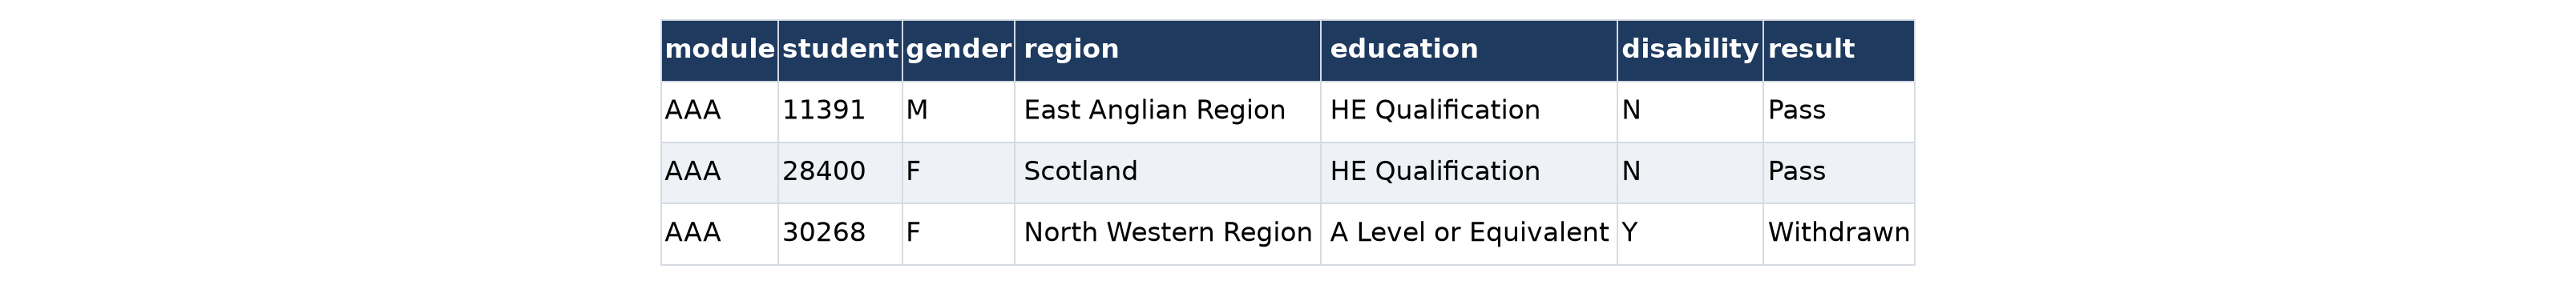

saved ..\..\docs\thesis\figures\oulad-studentinfo-sample.png


,module,student,gender,region,education,disability,result
0,AAA,11391,M,East Anglian Region,HE Qualification,N,Pass
1,AAA,28400,F,Scotland,HE Qualification,N,Pass
2,AAA,30268,F,North Western Region,A Level or Equivalent,Y,Withdrawn


In [2]:
info = pd.read_csv(os.path.join(RAW, "studentInfo.csv"))
info_sample = info[info["id_student"].isin([11391, 28400, 30268])][
    ["code_module", "id_student", "gender", "region", "highest_education", "disability", "final_result"]
].rename(columns={
    "code_module": "module", "id_student": "student", "highest_education": "education",
    "final_result": "result"
})
render_table(info_sample, "oulad-studentinfo-sample.png")
info_sample


## studentVle.csv — VLE interaction log

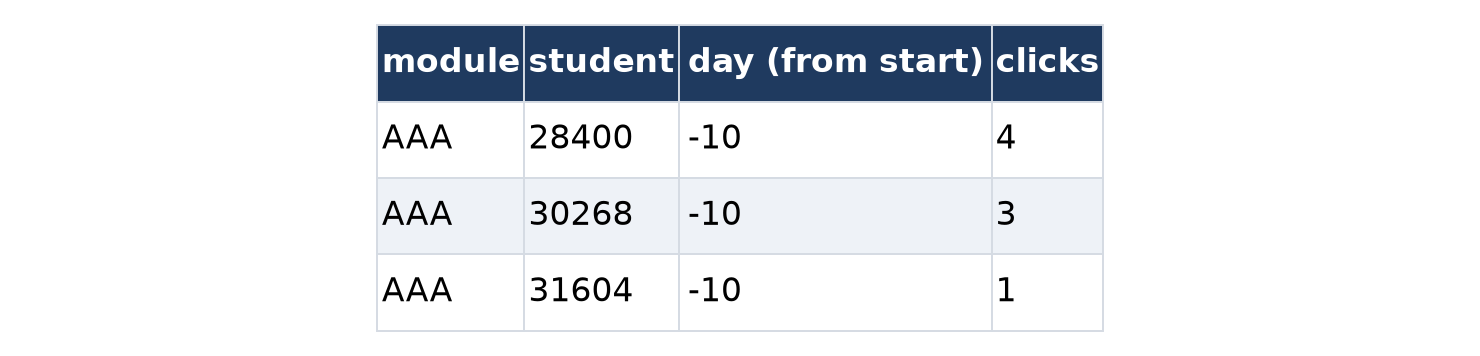

saved ..\..\docs\thesis\figures\oulad-vle-sample.png


,module,student,day (from start),clicks
0,AAA,28400,-10,4
14,AAA,30268,-10,3
18,AAA,31604,-10,1


In [3]:
vle = pd.read_csv(os.path.join(RAW, "studentVle.csv"))
vle_sample = vle[vle["id_student"].isin([28400, 30268, 31604])].drop_duplicates(
    "id_student"
)[["code_module", "id_student", "date", "sum_click"]].rename(columns={
    "code_module": "module", "id_student": "student", "date": "day (from start)", "sum_click": "clicks"
})
render_table(vle_sample, "oulad-vle-sample.png")
vle_sample


## assessments.csv — assessment definitions

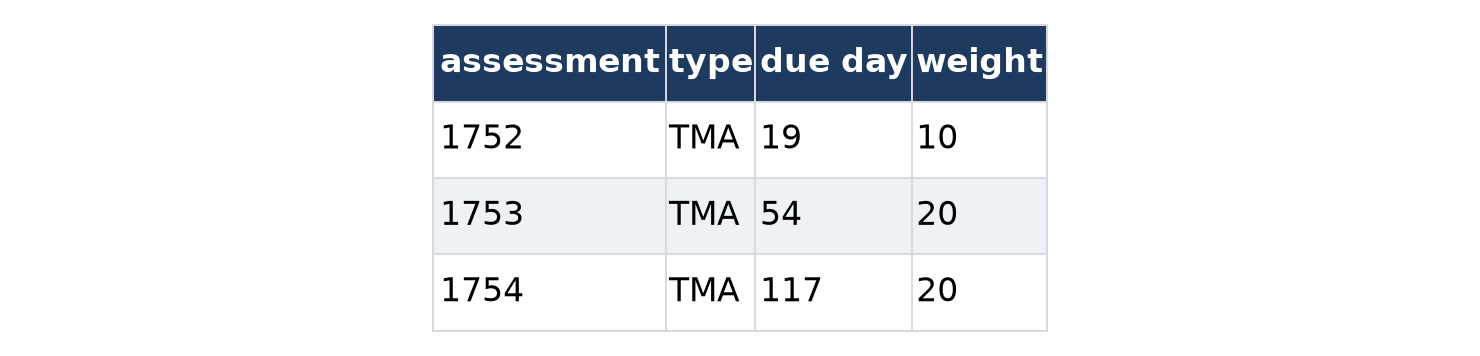

saved ..\..\docs\thesis\figures\oulad-assessments-sample.png


,assessment,type,due day,weight
0,1752,TMA,19,10
1,1753,TMA,54,20
2,1754,TMA,117,20


In [4]:
assess = pd.read_csv(os.path.join(RAW, "assessments.csv"))
assess_sample = assess[assess["id_assessment"].isin([1752, 1753, 1754])][
    ["id_assessment", "assessment_type", "date", "weight"]
].rename(columns={"id_assessment": "assessment", "assessment_type": "type", "date": "due day"})
assess_sample["due day"] = assess_sample["due day"].astype(int)
assess_sample["weight"] = assess_sample["weight"].astype(int)
render_table(assess_sample, "oulad-assessments-sample.png")
assess_sample


## studentAssessment.csv — submitted scores (the three submissions to assessment 1752 above)

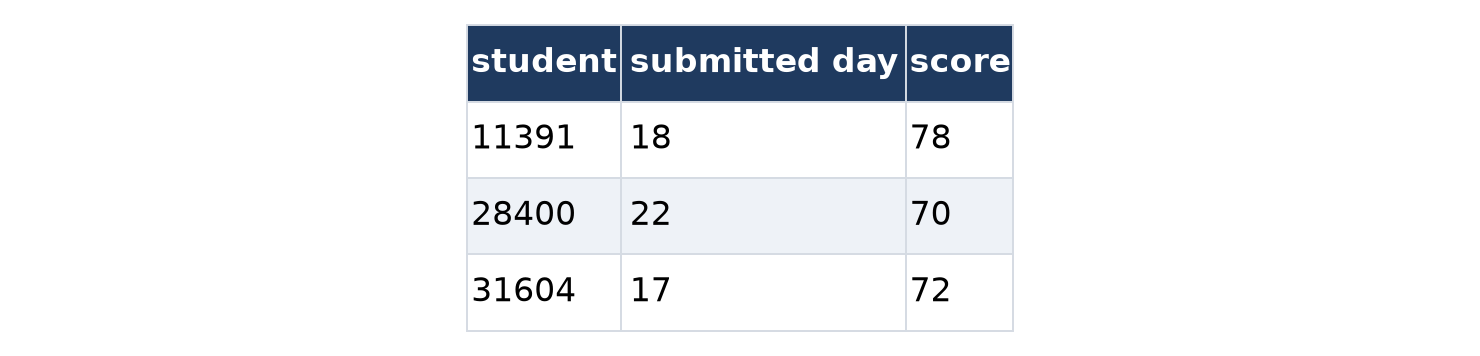

saved ..\..\docs\thesis\figures\oulad-studentassessment-sample.png


,student,submitted day,score
0,11391,18,78
1,28400,22,70
2,31604,17,72


In [5]:
sassess = pd.read_csv(os.path.join(RAW, "studentAssessment.csv"))
# id_assessment is only unique within a (module, presentation) pair, so this is
# further restricted to the same three students sampled from studentInfo/studentVle
# above, to keep the figures in the report consistent with each other.
sassess_sample = sassess[
    (sassess["id_assessment"] == 1752) & (sassess["id_student"].isin([11391, 28400, 31604]))
][["id_student", "date_submitted", "score"]].rename(
    columns={"id_student": "student", "date_submitted": "submitted day"}
)
sassess_sample = sassess_sample.astype(int)
render_table(sassess_sample, "oulad-studentassessment-sample.png")
sassess_sample
